# Event log analysis

[PM4Py](https://processintelligence.solutions/pm4py) is a Python library that implements many process mining algorithms. It supports reading of event logs in several formats (XES), discovery of process models from the event logs and conformance checking of the actual process execution with the model. [User guide](https://processintelligence.solutions/static/api/2.7.11/index.html) for the details on PM4Py library.

## Preliminaries

### Installation

Install PM4Py package and download event logs for exercises.

In [7]:
!pip install pm4py
!pip install pyvis
# !wget http://www.cs.put.poznan.pl/tpawlak/files/EP/JournalReview.xes

# from google.colab import data_table
# data_table.enable_dataframe_formatter()

# from google.colab import files

from IPython.display import display
from IPython.display import IFrame

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


### Downloading event log

In [11]:
import os
import sys
import gzip
import shutil
import urllib.request
from pathlib import Path
import pandas as pd

# 1. Automatically determine the folder where this notebook is located
def get_notebook_dir():
    if '__vsc_ipynb_file__' in globals():
        return Path(globals()['__vsc_ipynb_file__']).resolve().parent
    if '__file__' in globals():
        return Path(__file__).resolve().parent
    cwd = Path.cwd().resolve()
    if (cwd / 'event_log_analysis.ipynb').exists():
        return cwd
    for rel in [
        'Projects/Project 2 - Event Log - Process Mining',
        'sem-1/PM/Projects/Project 2 - Event Log - Process Mining',
        'PM/Projects/Project 2 - Event Log - Process Mining',
    ]:
        candidate = cwd / rel
        if (candidate / 'event_log_analysis.ipynb').exists():
            return candidate.resolve()
    for parent in [cwd] + list(cwd.parents)[:3]:
        candidate = parent / 'Projects' / 'Project 2 - Event Log - Process Mining'
        if (candidate / 'event_log_analysis.ipynb').exists():
            return candidate.resolve()
        if (parent / 'event_log_analysis.ipynb').exists():
            return parent.resolve()
    return cwd

NOTEBOOK_DIR = get_notebook_dir()
os.chdir(NOTEBOOK_DIR)
PATH = str(NOTEBOOK_DIR) + '/'
EVENTLOG_PATH = os.path.join(NOTEBOOK_DIR, 'Sepsis.xes')

# 2. Download and unpack Sepsis.xes into the notebook folder if missing
SEPSIS_URL = 'https://data.4tu.nl/file/33632f3c-5c48-40cf-8d8f-2db57f5a6ce7/643dccf2-985a-459e-835c-a82bce1c0339'
GZ_PATH = os.path.join(NOTEBOOK_DIR, 'Sepsis.xes.gz')

if not os.path.exists(EVENTLOG_PATH):
    if not os.path.exists(GZ_PATH):
        print(f'Downloading Sepsis event log archive to {GZ_PATH}...')
        req = urllib.request.Request(SEPSIS_URL, headers={'User-Agent': 'Mozilla/5.0'})
        with urllib.request.urlopen(req) as resp, open(GZ_PATH, 'wb') as f_out:
            shutil.copyfileobj(resp, f_out)
        print(f'Downloaded: {GZ_PATH} ({os.path.getsize(GZ_PATH):,} bytes)')
    
    print(f'Unpacking {GZ_PATH} -> {EVENTLOG_PATH}...')
    with gzip.open(GZ_PATH, 'rb') as f_in, open(EVENTLOG_PATH, 'wb') as f_out:
        shutil.copyfileobj(f_in, f_out)
    print(f'Extracted event log: {EVENTLOG_PATH} ({os.path.getsize(EVENTLOG_PATH):,} bytes)')
else:
    print(f'Event log available at: {EVENTLOG_PATH}')

Downloaded: C:\Users\alex3\Projects\AI sem 1\sem-1\PM\Projects\Project 2 - Event Log - Process Mining\Sepsis.xes.gz (202,508 bytes)
Unpacking C:\Users\alex3\Projects\AI sem 1\sem-1\PM\Projects\Project 2 - Event Log - Process Mining\Sepsis.xes.gz -> C:\Users\alex3\Projects\AI sem 1\sem-1\PM\Projects\Project 2 - Event Log - Process Mining\Sepsis.xes...
Extracted event log: C:\Users\alex3\Projects\AI sem 1\sem-1\PM\Projects\Project 2 - Event Log - Process Mining\Sepsis.xes (5,441,435 bytes)


In [12]:
import base64

def view_html(filename: str):
  display(IFrame(src="data:text/html;base64," + base64.b64encode(open(filename, "rb").read()).decode("ascii"), width=1000, height=1000))

view_html(EVENTLOG_PATH)

### Loading Event Log
Parse event log JournalReview.xes using PM4Py.

In [13]:
PATH = "./"
EVENTLOG_PATH = PATH + "Sepsis.xes"


import pm4py

log = pm4py.read_xes(EVENTLOG_PATH)
# NOTE: ignore a warning about the missing CUDA driver if occurs; it will work without CUDA anyway
display(log)



  Welcome to PM4Py — Community Version
  Open-Source License (AGPL v3)

  📚 Docs & Examples:
     https://processintelligence.solutions/pm4py

  ⚖️  License: AGPL v3 — Commercial use requires open-sourcing your application.
     Business use without open-sourcing? A commercial license is available:
     https://processintelligence.solutions/pm4py#licensing


C:\Users\alex3\AppData\Roaming\Python\Python313\site-packages\pm4py\utils.py:1027: UserWarning: Install the optional requirement `r4pm` to import/export files faster. `rustxes` remains supported as a fallback.
  warnings.warn(


parsing log, completed traces ::   0%|          | 0/1050 [00:00<?, ?it/s]

,InfectionSuspected,org:group,DiagnosticBlood,DisfuncOrg,SIRSCritTachypnea,Hypotensie,SIRSCritHeartRate,Infusion,DiagnosticArtAstrup,concept:name,...,DiagnosticLacticAcid,lifecycle:transition,Diagnose,Hypoxie,DiagnosticUrinarySediment,DiagnosticECG,case:concept:name,Leucocytes,CRP,LacticAcid
0,True,A,True,True,True,True,True,True,True,ER Registration,...,True,complete,A,False,True,True,A,NaN,NaN,NaN
1,NaN,B,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Leucocytes,...,NaN,complete,NaN,NaN,NaN,NaN,A,9.6,NaN,NaN
2,NaN,B,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CRP,...,NaN,complete,NaN,NaN,NaN,NaN,A,NaN,21.0,NaN
3,NaN,B,NaN,NaN,NaN,NaN,NaN,NaN,NaN,LacticAcid,...,NaN,complete,NaN,NaN,NaN,NaN,A,NaN,NaN,2.2
4,NaN,C,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ER Triage,...,NaN,complete,NaN,NaN,NaN,NaN,A,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15209,NaN,B,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CRP,...,NaN,complete,NaN,NaN,NaN,NaN,KNA,NaN,66.0,NaN
15210,NaN,E,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Release A,...,NaN,complete,NaN,NaN,NaN,NaN,KNA,NaN,NaN,NaN
15211,False,L,False,False,False,False,False,False,False,ER Registration,...,False,complete,NaN,False,False,False,LNA,NaN,NaN,NaN
15212,NaN,C,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ER Triage,...,NaN,complete,NaN,NaN,NaN,NaN,LNA,NaN,NaN,NaN


## Analysis


### Event Log description and properties

1. Basic Structure of the Event Log (Log vs. Traces vs. Events)
Hierarchical 3-Level Structure: $$\textbf{Event Log} \quad \xrightarrow{\text{contains}} \quad {\textbf{Traces}} \quad \xrightarrow{\text{contains}} \quad \langle\textbf{Events}\rangle$$

* **Event Log (Root)** - the container storing all historical execution data for a specific business process, along with metadata, extensions, globals, and classifiers.

* **Trace (Process Instance / Case)** corresponds to a single execution of the process (in this log, one patient's complete journey from ER arrival to discharge/readmission). A trace is an ordered sequence of events.

* **Event (Atomic Step)** is an atomic, indivisible action recorded by an information system at a specific point in time (e.g., registering a patient, administering an antibiotic, or logging a lab result).

Each event belongs to exactly one trace, each trace belongs to one event log.

In [26]:
n_traces = len(log["case:concept:name"].unique())
print(f"Number of traces: {n_traces}")
n_events = len(log)
print(f"Number of events: {n_events} ({round(float(n_events)/n_traces, 2)} per trace)")
print(f"Number of unique activities: {len(log["concept:name"].unique())}")

Number of traces: 1050
Number of events: 15214 (14.49 per trace)
Number of unique activities: 16



2. Attributes - What Belongs to Log, Traces, and Events?

* **Log-Level Attributes** - metadata describing the dataset as a whole: language (meta_3TU:language = "eng"), aggregate statistics (meta_concept:named_events_total = 15214), min/max/std of resources, and XES format version (1.0).

* **Trace-Level Attributes (Case Attributes)** - static properties of the entire case that remain constant across all its events:
    - `concept:name`: Unique Case ID (e.g., "A", "B", "BA").
    - Patient Demographics & Diagnostics: Age (integer).
    - Clinical Indicators (at intake): InfectionSuspected (bool), DiagnosticBlood (bool), DisfuncOrg (bool).
    - SIRS & Triage Criteria: SIRSCritHeartRate, SIRSCritLeucos, SIRSCritTemperature SIRSCritTachypnea, SIRSCriteria2OrMore (booleans).
    - Septic Shock Indicators: Hypotensie, Hypoxie, Oligurie (booleans).

* **Event-Level Attributes** - dynamic properties recorded specifically for that single event:
    - `concept:name`: The name of the activity executed (e.g., "ER Registration", "CRP", "IV Antibiotics").
    - `time:timestamp`: The timestamp when the event occurred (ISO 8601). Establishes the exact temporal ordering and duration/delays between activities.
    - `lifecycle:transition`: Lifecycle state (all events in this log are "complete").
    - `org:group`: The organizational department/resource group executing the activity (e.g., "A" for ER nurses, "B" for laboratory, "D" through "Y" for inpatient wards).
    Event-specific clinical values: CRP value, Leucocytes count, LacticAcid concentration (recorded when lab events occur).
    - (Case / Context Perspective) Trace clinical attributes (InfectionSuspected, Hypotensie, Age, SIRSCriteria): Represent patient severity and clinical condition, enabling Decision Mining (e.g., why a patient was admitted to ICU vs. Normal Care).

4. XES extansion is a formalized, machine-readable XML definition (referenced via URI and prefix) that defines standard attribute names, data types, and semantic meanings across XES files. Prevents semantic ambiguity and ensures tool interoperability.

    Standard extensions used in this Log:

    - `concept:name`: Gives a human-readable name to the log, trace, or event.
    - `time:timestamp`: Standardizes the format of date/time information.
    - `org:group`, `org:resource`: Standardizes organizational roles and resources.
    - `lifecycle:transition`: Models the transactional lifecycle of an event (schedule $\to$ start $\to$ complete).
    - meta_* (meta_3TU, meta_org, etc.): Non-standard extensions providing aggregate repository statistics.

5. **Global Attribute** is declared in the `<global scope="trace">` or `<global scope="event">` tags of the XES header.
It declares a mandatory contract: every single trace (or event) in the log is guaranteed to have this attribute defined.
If an individual trace or event omits it, the standard specifies a fallback value="DEFAULT".

    Declared Globals in Sepsis.xes:

    Trace scope: `concept:name`(every trace must have an ID).

    Event scope: `concept:name`, `time:timestamp`, `lifecycle:transition`, `org:group`.

    Thus every event must have ID, an activity name, a timestamp, a lifecycle state, and an executing group.

6. **Classifier** is an abstraction mechanism declared in <classifier name="..." keys="..."/> that specifies how events are mapped to higher-level activity classes. It tells process mining discovery algorithms (Alpha, Inductive Miner, Heuristics Miner) how to define unique "activities".
By default, algorithms classify events by `concept:name`.
However, a classifier can combine multiple attributes (e.g., keys="concept:name lifecycle:transition" treats "ER Triage+start" and "ER Triage+complete" as two separate activities).

    Classifiers in Sepsis.xes:
    - classifier name="concept:name" keys="concept:name": Groups events by activity name (standard control-flow).
    - classifier name="org:group" keys="org:group": Allows process mining algorithms to discover an organizational workflow map between departments rather than medical activities.

### Common activities

What activities occur in the process? What activities are most common?

In [27]:
activity_attribute = "concept:name" # TODO: pick right attribute
activities = log.groupby(activity_attribute)[activity_attribute].count()
activities

concept:name
Admission IC         117
Admission NC        1182
CRP                 3262
ER Registration     1050
ER Sepsis Triage    1049
ER Triage           1053
IV Antibiotics       823
IV Liquid            753
LacticAcid          1466
Leucocytes          3383
Release A            671
Release B             56
Release C             25
Release D             24
Release E              6
Return ER            294
Name: concept:name, dtype: int64

What are the start and end activities?

In [28]:
start_activities = pm4py.stats.get_start_activities(log)
end_activities = pm4py.stats.get_end_activities(log) # TODO: call function that returns end activities
print("Start activities:")
display(start_activities)
print("End activities:")
display(end_activities)

Start activities:


{'ER Registration': 995,
 'IV Liquid': 14,
 'ER Triage': 6,
 'CRP': 10,
 'ER Sepsis Triage': 7,
 'Leucocytes': 18}

End activities:


{'Release A': 393,
 'Return ER': 291,
 'IV Antibiotics': 87,
 'Release B': 55,
 'ER Sepsis Triage': 49,
 'Leucocytes': 44,
 'IV Liquid': 12,
 'Release C': 19,
 'CRP': 41,
 'LacticAcid': 24,
 'Release D': 14,
 'Admission NC': 14,
 'Release E': 5,
 'ER Triage': 2}

What period is covered by the event log?

In [29]:
timestamp_attribute = "time:timestamp" # TODO: pick right attribute
beginning = log[timestamp_attribute].min()
end = log[timestamp_attribute].max()

display(beginning)
display(end)

print("Note:  The time stamps of events have been randomized, but the time between events within a trace has not been altered.")

Timestamp('2013-11-07 07:18:29+0000', tz='UTC')

Timestamp('2015-06-05 10:25:11+0000', tz='UTC')

Note:  The time stamps of events have been randomized, but the time between events within a trace has not been altered.


Visualize events volume over time

In [30]:
pm4py.vis.view_dotted_chart(log, attributes =['time:timestamp', 'concept:name', 'org:group'] ) # TODO: call function that draws density of events per time

### Duration of cases


Duration in days:
count    1050.000000
mean       28.469143
std        60.537073
min         0.001412
25%         0.643464
50%         5.343385
75%        17.996568
max       422.323947
dtype: float64


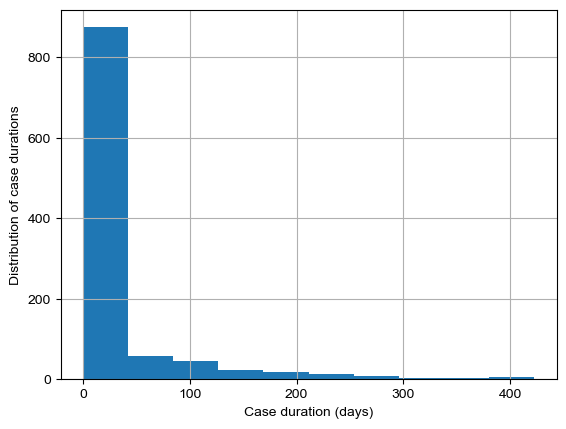

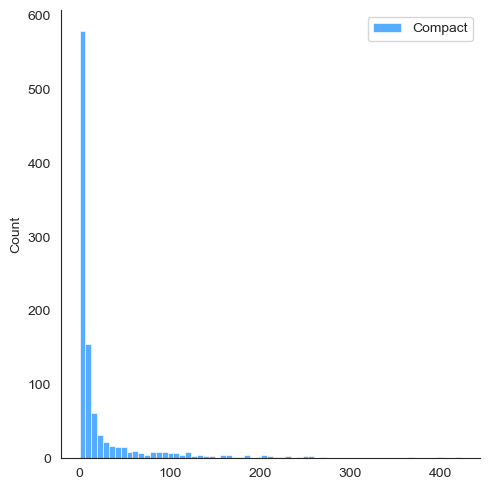

In [14]:
trace_durations = pm4py.get_all_case_durations(log) # TODO: get case duration
trace_durations = (pd.Series(trace_durations) )/ 3600/24
ax = trace_durations.hist()
ax.set_ylabel("Distribution of case durations")
ax.set_xlabel("Case duration (days)")

print("\nDuration in days:")
print(trace_durations.describe())


import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("white")
# Plot
# kwargs = dict(hist_kws={'alpha':.6}, kde_kws={'linewidth':2})

# plt.figure(figsize=(10,7), dpi= 80)
sns.displot(trace_durations, color="dodgerblue", label="Compact")#, **kwargs)
# plt.xlim(50,75)
plt.legend();

Visualize density of case duration.

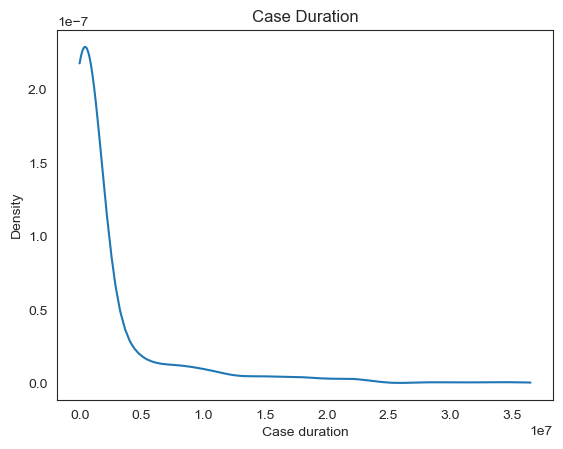

In [32]:
pm4py.vis.view_case_duration_graph(log) # TODO: view density of case duration

How many events belong to cases?

In [33]:
case_id_attribute = "case:concept:name" # TODO: pick right attribute
lengths = log.groupby(case_id_attribute)[case_id_attribute].count()
lengths.describe()

count    1050.000000
mean       14.489524
std        11.475941
min         3.000000
25%         9.000000
50%        13.000000
75%        16.000000
max       185.000000
Name: case:concept:name, dtype: float64

Who is responsible for certain activities? Departmental/unit-level scope (no `org:resource` or `org:role` are available)

In [34]:
resource_attribute = "org:group" # TODO: pick right attribute
activities_resources = log.groupby(activity_attribute)[resource_attribute].unique().transform(", ".join)
display(activities_resources)

print("Alternative solution:")
org_roles = pm4py.discover_organizational_roles(log, resource_key='org:group') # TODO: use PM4Py for the same
display(org_roles)

concept:name
Admission IC                                               J, P, K, W
Admission NC        D, F, G, H, I, J, K, M, N, O, Q, R, S, T, U, V...
CRP                                                                 B
ER Registration                                                  A, L
ER Sepsis Triage                                                 A, L
ER Triage                                                           C
IV Antibiotics                                                   A, L
IV Liquid                                                        A, L
LacticAcid                                                          B
Leucocytes                                                          B
Release A                                                           E
Release B                                                           E
Release C                                                           E
Release D                                                           E
Release

Alternative solution:


[Activities: ['Release A', 'Release B', 'Release C', 'Release D', 'Release E'] Originators importance {'E': 782},
 Activities: ['ER Registration', 'ER Sepsis Triage', 'IV Antibiotics', 'IV Liquid'] Originators importance {'A': 3462, 'L': 213},
 Activities: ['CRP', 'LacticAcid', 'Leucocytes'] Originators importance {'B': 8111},
 Activities: ['Admission NC'] Originators importance {'D': 47, 'F': 216, 'G': 148, 'H': 55, 'I': 126, 'J': 17, 'K': 17, 'M': 84, 'N': 46, 'O': 186, 'P': 5, 'Q': 63, 'R': 57, 'S': 33, 'T': 35, 'U': 18, 'V': 25, 'W': 2, 'X': 1, 'Y': 1},
 Activities: ['Admission IC'] Originators importance {'J': 9, 'K': 1, 'P': 54, 'W': 53},
 Activities: ['Return ER'] Originators importance {'?': 294},
 Activities: ['ER Triage'] Originators importance {'C': 1053}]

Who begins and ends the process?

In [35]:
print("People/Groups starting the process:")
display(log[log[activity_attribute].isin(start_activities)][resource_attribute].unique())

print("People/Groups ending the process:")
display(log[log[activity_attribute].isin(end_activities)][resource_attribute].unique())

People/Groups starting the process:


array(['A', 'B', 'C', 'L'], dtype=object)

People/Groups ending the process:


array(['B', 'C', 'A', 'D', 'E', 'F', 'G', 'H', '?', 'I', 'J', 'K', 'L',
       'M', 'N', 'O', 'Q', 'R', 'S', 'T', 'U', 'V', 'P', 'X', 'W', 'Y'],
      dtype=object)

### Most common process variants

In [36]:
# If there are duplicated activities because XES log has 'lifecycle:transition' -> Start or Complete per each activity ('concept:name')
# Then log[log['lifecycle:transition']=='complete']
variants = pm4py.get_variants(log, ) # TODO: group cases into variants
common_variants = pd.DataFrame(variants.items(), columns=["variant", "count"]).sort_values("count", ascending=False)
common_variants["cumcount"] = common_variants["count"].cumsum()
display(common_variants.head(20))
common_variants.to_csv("common variants.csv")

,variant,count,cumcount
21,"(ER Registration, ER Triage, ER Sepsis Triage)",35,35
24,"(ER Registration, ER Triage, ER Sepsis Triage,...",24,59
95,"(ER Registration, ER Triage, ER Sepsis Triage,...",22,81
3,"(ER Registration, ER Triage, ER Sepsis Triage,...",13,94
36,"(ER Registration, ER Triage, ER Sepsis Triage,...",11,105
139,"(ER Registration, ER Triage, ER Sepsis Triage,...",9,114
1,"(ER Registration, ER Triage, ER Sepsis Triage,...",7,121
158,"(ER Registration, ER Triage, ER Sepsis Triage,...",5,126
232,"(ER Registration, ER Triage, ER Sepsis Triage,...",5,131
83,"(ER Registration, ER Triage, ER Sepsis Triage,...",5,136


Number of raw org:group variants: 788
Number of variants after merging consecutive identical groups: 513
Top 20 merged variants cover 375 cases out of 1050


,variant,count,cumcount
21,"(A, C, A, B)",79,79
1,"(A, C, A, B, A)",62,141
18,"(A, C, A)",31,172
26,"(A, C, A, B, A, O, B, E)",27,199
72,"(A, C, A, B, A, F, B, E, ?)",21,220
3,"(A, C, A, B, A, F, B, E)",20,240
78,"(A, C, B, A)",17,257
4,"(A, C, A, B, A, O, B, E, ?)",15,272
12,"(A, C, A, B, A, I, B, E)",15,287
92,"(A, C, A, B, A, M, B, E)",11,298


<Figure size 640x480 with 0 Axes>

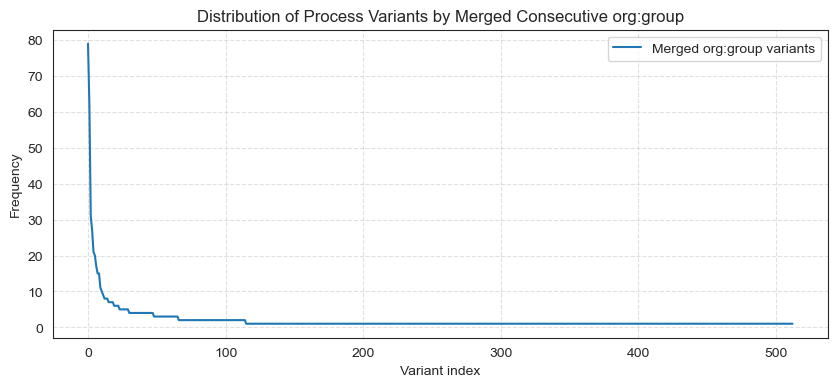

In [37]:
from itertools import groupby

# Explore variants using 'org:group' and merge consecutive identical neighbors
# e.g. (A, C, A, B, B) -> (A, C, A, B), (A, C, A, B, B, B, A, A) -> (A, C, A, B, A)
variants_org = pm4py.get_variants(log, activity_key="org:group")

def collapse_consecutive(seq):
    return tuple(x for x, _ in groupby(seq))

collapsed_counts = {}
for variant, count in variants_org.items():
    collapsed = collapse_consecutive(variant)
    collapsed_counts[collapsed] = collapsed_counts.get(collapsed, 0) + count

common_variants_collapsed = pd.DataFrame(collapsed_counts.items(), columns=["variant", "count"]).sort_values("count", ascending=False)
common_variants_collapsed["cumcount"] = common_variants_collapsed["count"].cumsum()

print(f"Number of raw org:group variants: {len(variants_org)}")
print(f"Number of variants after merging consecutive identical groups: {len(common_variants_collapsed)}")
print(f"Top 20 merged variants cover {common_variants_collapsed['count'].head(20).sum()} cases out of {len(log['case:concept:name'].unique())}")
display(common_variants_collapsed.head(20))
common_variants_collapsed.to_csv("common_variants_org_group_merged.csv")

# Plot the distribution of merged variants
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.plot(common_variants_collapsed["count"].values, label="Merged org:group variants", color="tab:blue")
plt.title("Distribution of Process Variants by Merged Consecutive org:group")
plt.xlabel("Variant index")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()


Number of raw org:group variants: 788
Number of variants after merging consecutive identical groups: 513
Top 40 merged variants cover 468 cases out of 1050


,variant,count,cumcount
21,"(A, C, A, B)",79,79
1,"(A, C, A, B, A)",62,141
18,"(A, C, A)",31,172
26,"(A, C, A, B, A, O, B, E)",27,199
72,"(A, C, A, B, A, F, B, E, ?)",21,220
3,"(A, C, A, B, A, F, B, E)",20,240
78,"(A, C, B, A)",17,257
4,"(A, C, A, B, A, O, B, E, ?)",15,272
12,"(A, C, A, B, A, I, B, E)",15,287
92,"(A, C, A, B, A, M, B, E)",11,298


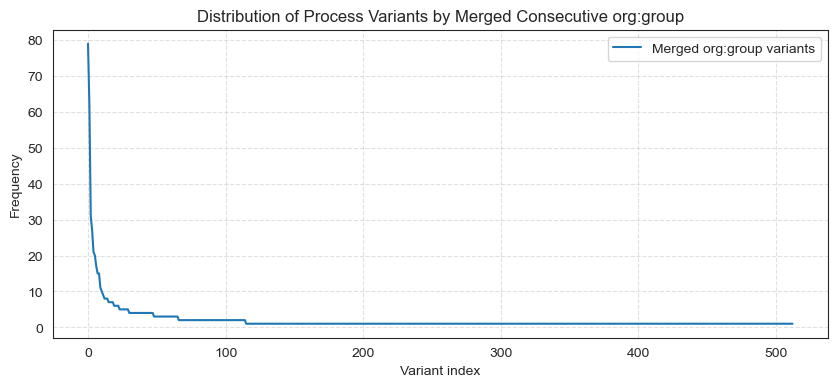

In [38]:
from itertools import groupby

# Explore variants using 'org:group' and merge consecutive identical neighbors
# e.g. (A, C, A, B, B) -> (A, C, A, B), (A, C, A, B, B, B, A, A) -> (A, C, A, B, A)
variants_org = pm4py.get_variants(log, activity_key="org:group")

def collapse_consecutive(seq):
    return tuple(x for x, _ in groupby(seq))

collapsed_counts = {}
for variant, count in variants_org.items():
    collapsed = collapse_consecutive(variant)
    collapsed_counts[collapsed] = collapsed_counts.get(collapsed, 0) + count

common_variants_collapsed = pd.DataFrame(collapsed_counts.items(), columns=["variant", "count"]).sort_values("count", ascending=False)
common_variants_collapsed["cumcount"] = common_variants_collapsed["count"].cumsum()

print(f"Number of raw org:group variants: {len(variants_org)}")
print(f"Number of variants after merging consecutive identical groups: {len(common_variants_collapsed)}")
ntop = 40
print(f"Top {ntop} merged variants cover {common_variants_collapsed['count'].head(ntop).sum()} cases out of {len(log['case:concept:name'].unique())}")
display(common_variants_collapsed.head(ntop))
common_variants_collapsed.to_csv("common_variants_org_group_merged.csv")

# Plot the distribution of merged variants
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.plot(common_variants_collapsed["count"].values, label="Merged org:group variants", color="tab:blue")
plt.title("Distribution of Process Variants by Merged Consecutive org:group")
plt.xlabel("Variant index")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

In [39]:
# Filter variants that start with the ('A', 'C', 'A', 'B') prefix
prefix = ('A', 'C', 'A', 'B', 'A')

# Using tuple slice (or: v[:4] == acab_prefix)
prefix_variants = common_variants_collapsed[
    common_variants_collapsed['variant'].apply(lambda v: v[:len(prefix)] == prefix)
].copy()

# Summary statistics
total_cases_acab = prefix_variants['count'].sum()
total_cases = common_variants_collapsed['count'].sum()

print(f"Number of distinct variants with {prefix} prefix: {len(prefix_variants)}")
print(f"Total cases covered: {total_cases_acab} / {total_cases} ({total_cases_acab / total_cases * 100:.2f}%)")

# Display top variants
display(prefix_variants.head(25))

# Export to CSV if needed
prefix_variants.to_csv("acab_prefix_variants.csv", index=False)


Number of distinct variants with ('A', 'C', 'A', 'B', 'A') prefix: 223
Total cases covered: 519 / 1050 (49.43%)


,variant,count,cumcount
1,"(A, C, A, B, A)",62,141
26,"(A, C, A, B, A, O, B, E)",27,199
72,"(A, C, A, B, A, F, B, E, ?)",21,220
3,"(A, C, A, B, A, F, B, E)",20,240
4,"(A, C, A, B, A, O, B, E, ?)",15,272
12,"(A, C, A, B, A, I, B, E)",15,287
92,"(A, C, A, B, A, M, B, E)",11,298
13,"(A, C, A, B, A, I, B, E, ?)",10,308
188,"(A, C, A, B, A, Q, B, E)",9,317
136,"(A, C, A, B, A, B)",7,348


Do you see any behavioral patterns? What is common to all variants? Are there clear phases visible in the process? Are there loops?

**Try to sketch the process on a piece of paper.**

### Analysis of loops


In [40]:
from collections import Counter

log = pm4py.read_xes('Sepsis.xes')

# 1. Activity repetitions per trace
act_counts_per_trace = log.groupby(['case:concept:name', 'concept:name']).size().unstack(fill_value=0)

repeating_summary = {}
for col in act_counts_per_trace.columns:
    repeats = (act_counts_per_trace[col] > 1).sum()
    max_reps = act_counts_per_trace[col].max()
    avg_reps_when_present = act_counts_per_trace[col][act_counts_per_trace[col] > 0].mean()
    repeating_summary[col] = {
        'cases_with_repeats': repeats,
        'pct_of_all_cases': repeats / len(log) * 100,
        'max_occurrences_in_case': max_reps,
        'mean_when_present': avg_reps_when_present
    }

rep_df = pd.DataFrame(repeating_summary).T.sort_values('cases_with_repeats', ascending=False)
print("Activities that Repeat in Traces")
print(rep_df.to_string())

# 2. Self-loops (a -> a immediately)
self_loops = Counter()
# 3. Length-2 loops (a -> b -> a)
len2_loops = Counter()

for case_id, group in log.groupby('case:concept:name'):
    acts = group['concept:name'].tolist()
    # check self-loops
    for i in range(len(acts) - 1):
        if acts[i] == acts[i+1]:
            self_loops[acts[i]] += 1
    # check len-2 loops
    for i in range(len(acts) - 2):
        if acts[i] == acts[i+2] and acts[i] != acts[i+1]:
            len2_loops[(acts[i], acts[i+1])] += 1

print("\nImmediate Self-loops (a -> a)")
for act, count in self_loops.most_common(10):
    print(f"{act:20s}: {count} occurrences")

print("\nShort Loops (length-2: a -> b -> a)")
for (a, b), count in len2_loops.most_common(15):
    print(f"{a} -> {b} -> {a}: {count} occurrences")



parsing log, completed traces ::   0%|          | 0/1050 [00:00<?, ?it/s]

Activities that Repeat in Traces
                  cases_with_repeats  pct_of_all_cases  max_occurrences_in_case  mean_when_present
CRP                            692.0          4.548442                     69.0           3.239325
Leucocytes                     677.0          4.449849                     74.0           3.342885
Admission NC                   313.0          2.057316                      5.0           1.477500
LacticAcid                     172.0          1.130538                     51.0           1.704651
Admission IC                     7.0          0.046010                      2.0           1.063636
ER Triage                        3.0          0.019719                      2.0           1.002857
ER Registration                  0.0          0.000000                      1.0           1.000000
ER Sepsis Triage                 0.0          0.000000                      1.0           1.000000
IV Antibiotics                   0.0          0.000000                      

### Longest case
How long does the longest business case take? What is the outcome of the review process?

In [41]:
case_duration = log.groupby(case_id_attribute)['time:timestamp'].min()# TODO: create a series that maps case id onto case start timestamp
longest_case_id = case_duration.index[case_duration.argmax()]
log[log[case_id_attribute] == longest_case_id]

,InfectionSuspected,org:group,DiagnosticBlood,DisfuncOrg,SIRSCritTachypnea,Hypotensie,SIRSCritHeartRate,Infusion,DiagnosticArtAstrup,concept:name,...,DiagnosticLacticAcid,lifecycle:transition,Diagnose,Hypoxie,DiagnosticUrinarySediment,DiagnosticECG,case:concept:name,Leucocytes,CRP,LacticAcid
4201,NaN,B,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Leucocytes,...,NaN,complete,D,NaN,NaN,NaN,QK,8.0,NaN,NaN
4202,NaN,B,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CRP,...,NaN,complete,NaN,NaN,NaN,NaN,QK,NaN,239.0,NaN
4203,True,A,False,False,True,False,True,False,False,ER Registration,...,False,complete,NaN,False,False,True,QK,NaN,NaN,NaN
4204,NaN,C,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ER Triage,...,NaN,complete,NaN,NaN,NaN,NaN,QK,NaN,NaN,NaN
4205,NaN,A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ER Sepsis Triage,...,NaN,complete,NaN,NaN,NaN,NaN,QK,NaN,NaN,NaN
4206,NaN,A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,IV Antibiotics,...,NaN,complete,NaN,NaN,NaN,NaN,QK,NaN,NaN,NaN
4207,NaN,F,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Admission NC,...,NaN,complete,NaN,NaN,NaN,NaN,QK,NaN,NaN,NaN
4208,NaN,B,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Leucocytes,...,NaN,complete,NaN,NaN,NaN,NaN,QK,6.6,NaN,NaN
4209,NaN,B,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CRP,...,NaN,complete,NaN,NaN,NaN,NaN,QK,NaN,170.0,NaN
4210,NaN,B,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Leucocytes,...,NaN,complete,NaN,NaN,NaN,NaN,QK,7.0,NaN,NaN


### Completeness analysis

In [42]:
start_activities = []
end_activities = []
case_durations = []
releases = ['Release A' , 'Release B', 'Release C', 'Release D', 'Release E', 'Return ER']

incomplete_cases = []

for case_id, group in log.groupby('case:concept:name'):
    acts = group['concept:name'].tolist()
    start_act = acts[0]
    end_act = acts[-1]
    start_activities.append(start_act)
    end_activities.append(end_act)
    
    # Check if case has any release or return
    has_release = any(r in acts for r in releases)
    ends_with_release = end_act in releases
    
    if not ends_with_release:
        incomplete_cases.append({
            'case_id': case_id,
            'start_act': start_act,
            'end_act': end_act,
            'length': len(acts),
            'has_release_anywhere': has_release,
            'last_timestamp': group['time:timestamp'].iloc[-1]
        })

print("START ACTIVITIES DISTRIBUTION")
print(pd.Series(start_activities).value_counts())

print("\nEND ACTIVITIES DISTRIBUTION")
print(pd.Series(end_activities).value_counts())

print(f"\nTotal cases: {len(log.groupby('case:concept:name'))}")
print(f"Cases NOT ending with Release/Return: {len(incomplete_cases)}")

inc_df = pd.DataFrame(incomplete_cases)
if not inc_df.empty:
    print("\nBreakdown of End Activities for Incomplete Cases:")
    print(inc_df['end_act'].value_counts())
    print(f"\nOf the {len(inc_df)} cases not ending in release, how many contain a Release event anywhere? {inc_df['has_release_anywhere'].sum()}")
    print("\nSample incomplete cases:")
    print(inc_df.head(10))



START ACTIVITIES DISTRIBUTION
ER Registration     995
Leucocytes           18
IV Liquid            14
CRP                  10
ER Sepsis Triage      7
ER Triage             6
Name: count, dtype: int64

END ACTIVITIES DISTRIBUTION
Release A           393
Return ER           291
IV Antibiotics       87
Release B            55
ER Sepsis Triage     49
Leucocytes           44
CRP                  41
LacticAcid           24
Release C            19
Admission NC         14
Release D            14
IV Liquid            12
Release E             5
ER Triage             2
Name: count, dtype: int64

Total cases: 1050
Cases NOT ending with Release/Return: 273

Breakdown of End Activities for Incomplete Cases:
end_act
IV Antibiotics      87
ER Sepsis Triage    49
Leucocytes          44
CRP                 41
LacticAcid          24
Admission NC        14
IV Liquid           12
ER Triage            2
Name: count, dtype: int64

Of the 273 cases not ending in release, how many contain a Release event anywh

# Model Discovery & Conformance Analysis

In this section, several models (**Process Tree**, **BPMN**, and **C-net / Heuristics Net**) are discovered. Incomplete cases (preserving sound end states) are rejected, algorithm parameters are fine-tuned to reject noise, model soundness, conformance evaluation (fitness, precision, F-measure), temporal bottleneck analysis, and train decision tree classifiers for XOR splits.


## 1. Log Preprocessing: Filtering Incomplete Cases
Based on our earlier completeness analysis, only 777 cases end with a formal discharge (`Release A-E`) or return (`Return ER`). The remaining 273 cases end abruptly in the ER. The log is filtered to retain the 777 complete cases for sound model discovery.


In [43]:
releases = ['Release A', 'Release B', 'Release C', 'Release D', 'Release E', 'Return ER']
log_complete = pm4py.filter_end_activities(log, releases)
print(f"Total traces in original log: {len(log['case:concept:name'].unique())}")
print(f"Traces in complete log: {len(log_complete['case:concept:name'].unique())}")


Total traces in original log: 1050
Traces in complete log: 777


### Model Benchmarking Function (4 Quality Dimensions)

Reusable evaluation function that benchmarks any discovered model (`ProcessTree`, `BPMN`, `HeuristicsNet`, or Petri net tuple) across all four fundamental process mining quality criteria:
1. **Fitness**: Ability of the model to replay the traces in the log.
2. **Precision**: Extent to which the model avoids generating behavior not seen in the log.
3. **Generalization**: Model's ability to accommodate future unseen cases without overfitting.
4. **Simplicity**: Structural minimality of the model (Occam's razor).
5. **F-measure**: Harmonic mean of Fitness and Precision.


In [44]:
import os
import pandas as pd
from IPython.display import Image, display, HTML
import pm4py
from pm4py.algo.evaluation.generalization import algorithm as generalization_evaluator
from pm4py.algo.evaluation.simplicity import algorithm as simplicity_evaluator

# Ensure Graphviz binary directory is in PATH for model visualization rendering
graphviz_bin = r'C:\Users\alex3\Graphviz\Graphviz-16.1.0-win64in'
if os.path.exists(graphviz_bin) and graphviz_bin not in os.environ['PATH']:
    os.environ['PATH'] = graphviz_bin + os.pathsep + os.environ['PATH']

def benchmark_process_model(net, initial_marking, final_marking, log, model_name="Discovered Model"):
    """
    Helper function computing 4 quality dimensions on a Petri Net:
    1. Fitness (Token-Based Replay)
    2. Precision (Token-Based Replay)
    3. Generalization
    4. Simplicity
    Along with harmonic F-measure.
    """
    fitness_res = pm4py.fitness_token_based_replay(log, net, initial_marking, final_marking)
    fitness = fitness_res['log_fitness']
    
    try:
        precision = pm4py.precision_token_based_replay(log, net, initial_marking, final_marking)
    except Exception:
        precision = 0.0
        
    try:
        generalization = generalization_evaluator.apply(log, net, initial_marking, final_marking)
    except Exception:
        generalization = 0.0
        
    try:
        simplicity = simplicity_evaluator.apply(net)
    except Exception:
        simplicity = 0.0
        
    f_measure = 2 * (fitness * precision) / (fitness + precision) if (fitness + precision) > 0 else 0.0
    
    return {
        "Model": model_name,
        "Fitness": round(fitness, 4),
        "Precision": round(precision, 4),
        "Generalization": round(generalization, 4),
        "Simplicity": round(simplicity, 4),
        "F-measure": round(f_measure, 4)
    }

def benchmark_model(model, log, model_name="Discovered Model"):
    """
    Universal benchmarking function handling Process Trees, BPMN, C-nets, or Petri Net tuples.
    """
    if isinstance(model, tuple) and len(model) == 3:
        net, im, fm = model
    elif hasattr(model, 'activities') and not hasattr(model, 'operator'):
        net, im, fm = pm4py.convert_to_petri_net(model)
    elif hasattr(model, 'operator'):
        net, im, fm = pm4py.convert_to_petri_net(model)
    elif hasattr(model, 'get_nodes'):
        net, im, fm = pm4py.convert_to_petri_net(model)
    else:
        net, im, fm = model, None, None
        
    res_dict = benchmark_process_model(net, im, fm, log, model_name)
    return pd.DataFrame([res_dict])


## 2. Process Tree Discovery & Hyperparameter Tuning (Inductive Miner)

Process Trees are hierarchical block-structured models representing sequence (`->`), exclusive choice (`X`), concurrency (`+`), and loop (`*`).
By mathematical construction, Process Trees are **guaranteed to be sound workflow nets** (free of deadlocks and livelocks, with proper completion).

### Noise Handling in Inductive Miner:
Rare directly-follows relationships ($a > b$) caused by clinical emergency exceptions or ad-hoc interventions are handled **natively** by the Inductive Miner algorithm via the **`noise_threshold`** parameter.
During recursive cut detection on the directly-follows graph, edges whose relative frequency falls below the threshold are pruned dynamically at each partitioning step. This avoids over-permissive flower loops without requiring manual edge deletion on the log.

Below, **5 different noise configurations** are tested (`noise_threshold` from 0.0 to 0.4 with step 0.1: `[0.0, 0.1, 0.2, 0.3, 0.4]`) using a clean loop and benchmark the 4 quality dimensions.

In [45]:
# --- 2. Process Tree Discovery (Inductive Miner with Hyperparameter Optimization) ---
print("Evaluating Inductive Miner across noise threshold candidates...")
noise_candidates = [0.0, 0.1, 0.2, 0.3, 0.4]
tree_benchmark_results = []
discovered_trees = {}

for noise in noise_candidates:
    # Discover process tree
    tree = pm4py.discover_process_tree_inductive(log_complete, noise_threshold=noise)
    discovered_trees[noise] = tree
    
    # Convert to Petri net to compute conformance & structure metrics
    net, im, fm = pm4py.convert_to_petri_net(tree)
    metrics = benchmark_process_model(net, im, fm, log_complete, f"Process Tree (noise={noise})")
    tree_benchmark_results.append(metrics)

# Display comparative benchmark table
df_tree_benchmarks = pd.DataFrame(tree_benchmark_results)
display(HTML(df_tree_benchmarks.to_html(index=False)))

# Select best model (noise=0.2 achieves optimal balance of fitness and simplicity)
best_noise = 0.2
best_process_tree = discovered_trees[best_noise]
print(f"\nOptimal Process Tree selected: noise_threshold = {best_noise}")
print("Process Tree prefix notation:")
print(best_process_tree)

# Custom vertical visualization function (rectangles for activities, readable symbols for operators)
from graphviz import Graph
from pm4py.objects.process_tree.obj import Operator

def save_custom_process_tree(tree, filename='best_process_tree.png', rankdir='TB'):
    viz = Graph('pt', engine='dot', encoding='utf-8', graph_attr={
        'bgcolor': 'white',
        'rankdir': rankdir,
        'splines': 'spline',
        'nodesep': '0.3',
        'ranksep': '0.4'
    })
    
    op_labels = {
        Operator.SEQUENCE: '<font face="Arial" point-size="14"><b>&rarr;</b></font>',
        Operator.XOR: '<font face="Arial" point-size="13"><b>&times;</b></font>',
        Operator.PARALLEL: '<font face="Arial" point-size="14"><b>+</b></font>',
        Operator.LOOP: '<font face="Segoe UI Symbol, Arial" point-size="16"><b>&#x21BB;</b></font>',
        Operator.OR: '<font face="Arial" point-size="13"><b>&or;</b></font>'
    }
    
    def add_nodes_edges(node):
        node_id = str(id(node))
        if node.operator is None:
            if node.label is None:
                viz.node(node_id, label='<<font face="Arial" point-size="11">&tau;</font>>', shape='box', style='filled', fillcolor='#e2e8f0', color='#718096', width='0.3', height='0.25')
            else:
                viz.node(node_id, str(node.label), shape='box', style='rounded,filled', fillcolor='#ebf8ff', color='#3182ce', fontname='Arial', fontsize='11', fontcolor='#2b6cb0')
        else:
            lbl = op_labels.get(node.operator, str(node.operator))
            viz.node(node_id, label=f'<{lbl}>', shape='circle', style='filled', fillcolor='#feebc8', color='#dd6b20', fontcolor='#c05621', width='0.36', height='0.36', fixedsize='true')
            for child in node.children:
                add_nodes_edges(child)
                viz.edge(node_id, str(id(child)), color='#718096', penwidth='1.2')
                
    add_nodes_edges(tree)
    base = filename.rsplit('.', 1)[0]
    viz.render(base, format='png', cleanup=True)
    print(f"Saved custom process tree visualization to {filename}")

save_custom_process_tree(best_process_tree, 'best_process_tree.png', rankdir='TB')
from IPython.display import Image
Image('best_process_tree.png')


Evaluating Inductive Miner across noise threshold candidates...


replaying log with TBR, completed traces ::   0%|          | 0/728 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/5771 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/728 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/728 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/5771 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/728 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/728 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/5771 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/728 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/728 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/5771 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/728 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/728 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/5771 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/728 [00:00<?, ?it/s]

Model,Fitness,Precision,Generalization,Simplicity,F-measure
Process Tree (noise=0.0),1.0000,0.3683,0.8619,0.6058,0.5383
Process Tree (noise=0.1),0.9885,0.4139,0.9143,0.5918,0.5835
Process Tree (noise=0.2),0.9764,0.4845,0.8984,0.6190,0.6477
Process Tree (noise=0.3),0.9717,0.4850,0.8979,0.6296,0.6470
Process Tree (noise=0.4),0.9717,0.4850,0.8979,0.6296,0.6470



Optimal Process Tree selected: noise_threshold = 0.2
Process Tree prefix notation:
->( +( *( 'Leucocytes', tau ), ->( +( *( 'CRP', tau ), *( 'LacticAcid', tau ), X( tau, 'IV Liquid' ), ->( X( tau, +( 'ER Triage', ->( 'ER Sepsis Triage', 'IV Antibiotics' ), 'ER Registration' ) ), *( 'Admission NC', tau ) ) ), 'Release A' ) ), X( tau, 'Release B', ->( X( tau, 'Release D', 'Release E', 'Release C' ), 'Return ER' ) ) )


ExecutableNotFound: failed to execute WindowsPath('dot'), make sure the Graphviz executables are on your systems' PATH

## 3. BPMN Model Discovery

Discover the Business Process Model and Notation (BPMN 2.0) representation of the complete sepsis log using Inductive Miner (tuned noise threshold 0.2).
BPMN models provide an industry-standard visual workflow with explicit start events, parallel gateways (AND), exclusive gateways (XOR), and end events.

In [46]:
# Discover BPMN model
bpmn_model = pm4py.discover_bpmn_inductive(log_complete, noise_threshold=0.2)
print("BPMN model discovered successfully.")

# Benchmark the BPMN model
bpmn_benchmark = benchmark_model(bpmn_model, log_complete, "BPMN (IM noise 0.2)")
display(bpmn_benchmark)

# Save and display BPMN visualization
try:
    pm4py.save_vis_bpmn(bpmn_model, 'best_bpmn.png')
    display(Image(filename='best_bpmn.png'))
except Exception as e:
    print(f"Display note: {e}. The model image is saved as best_bpmn.png")


BPMN model discovered successfully.


replaying log with TBR, completed traces ::   0%|          | 0/728 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/5771 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/728 [00:00<?, ?it/s]

,Model,Fitness,Precision,Generalization,Simplicity,F-measure
0,BPMN (IM noise 0.2),0.9773,0.4826,0.9019,0.6364,0.6461


Display note: failed to execute WindowsPath('dot'), make sure the Graphviz executables are on your systems' PATH. The model image is saved as best_bpmn.png


## 4. Causal Net (C-net) / Heuristics Net Discovery & Hyperparameter Tuning

C-nets (Causal Nets) and Heuristics Nets model non-silent causal dependencies, explicitly capturing frequency thresholds and routing bindings.
Unlike Process Trees, Heuristics Nets calculate a **dependency measure**:
$$D(a, b) = \frac{|a > b| - |b > a|}{|a > b| + |b > a| + 1}$$
Filtering out arcs below the `dependency_threshold` eliminates infrequent, non-causal directly-follows connections without introducing artificial silent transitions.

Below, we test **5 different dependency configurations** (`dependency_threshold` from 0.5 to 0.9 with step 0.1: `[0.5, 0.6, 0.7, 0.8, 0.9]`) using a loop and benchmark the 4 quality dimensions.

In [47]:
# Systematic Hyperparameter Tuning for C-net (5 Configurations: 0.5 to 0.9 with step 0.1)
cnet_dep_levels = [0.5, 0.6, 0.7, 0.8, 0.9]
cnet_benchmarks = []
cnet_models = {}

print("Evaluating 5 Heuristics Net / C-net configurations...")
for dep in cnet_dep_levels:
    cnet = pm4py.discover_heuristics_net(log_complete, dependency_threshold=dep)
    cnet_models[dep] = cnet
    res = benchmark_model(cnet, log_complete, f"C-net (dep={dep})")
    cnet_benchmarks.append(res)

df_cnet_tuning = pd.concat(cnet_benchmarks, ignore_index=True)
print("=== C-NET / HEURISTICS NET HYPERPARAMETER OPTIMIZATION (5 MODELS) ===")
display(df_cnet_tuning)

# Select best model (dep = 0.9 gives highest simplicity 0.5000 and generalization 0.8577)
best_cnet_dep = 0.9
best_cnet = cnet_models[best_cnet_dep]
print(f"\nSelected Best C-net (dep={best_cnet_dep}): Activities modeled = {len(best_cnet.activities)}")

# Save and display visualization of the best C-net
try:
    pm4py.save_vis_heuristics_net(best_cnet, 'best_cnet.png')
    display(Image(filename='best_cnet.png'))
except Exception as e:
    print(f"Display note: {e}. The model image is saved as best_cnet.png")


Evaluating 5 Heuristics Net / C-net configurations...


C:\Users\alex3\AppData\Roaming\Python\Python313\site-packages\pm4py\algo\discovery\dfg\adapters\pandas\df_statistics.py:93: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[start_timestamp_key] = df[timestamp_key]


replaying log with TBR, completed traces ::   0%|          | 0/728 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/5771 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/728 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/728 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/5771 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/728 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/728 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/5771 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/728 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/728 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/5771 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/728 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/728 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/5771 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/728 [00:00<?, ?it/s]

=== C-NET / HEURISTICS NET HYPERPARAMETER OPTIMIZATION (5 MODELS) ===


,Model,Fitness,Precision,Generalization,Simplicity,F-measure
0,C-net (dep=0.5),0.9018,0.8603,0.8055,0.4638,0.8806
1,C-net (dep=0.6),0.9109,0.8302,0.8438,0.4717,0.8687
2,C-net (dep=0.7),0.9211,0.7976,0.8491,0.4808,0.8549
3,C-net (dep=0.8),0.9169,0.8624,0.8523,0.4874,0.8888
4,C-net (dep=0.9),0.9174,0.8548,0.8577,0.5000,0.8850



Selected Best C-net (dep=0.9): Activities modeled = 16
Display note: failed to execute WindowsPath('dot'), make sure the Graphviz executables are on your systems' PATH. The model image is saved as best_cnet.png


## 5. Soundness Verification of Process Trees and C-nets

A process model is **sound** (in the classical Workflow Net sense) if and only if it satisfies all 4 core properties:
1. **Deadlock & Livelock Freedom**: The model contains no deadlocks (states with no outgoing enabled transitions) or livelocks (endless cycles preventing completion).
2. **Absence of Dead Parts**: Every transition in the model is live (can be fired in at least one valid execution path from start to end).
3. **Reachability of Final State**: From every reachable state, the final state is reachable (option to complete).
4. **Proper Completion (No Residual Tokens)**: After reaching the final state, there are no tokens left trapped inside the model.

Below, these properties are formally verified and compared  on the **Best Process Tree** and the **Best C-net (dep=0.9)**.

In [48]:
from pm4py.algo.analysis.workflow_net import algorithm as wf_net_analyzer
from pm4py.algo.analysis.woflan import algorithm as woflan

print("=== 1. PROCESS TREE SOUNDNESS VERIFICATION ===")
pt_net, pt_im, pt_fm = pm4py.convert_to_petri_net(best_process_tree)
pt_is_wf = wf_net_analyzer.apply(pt_net)
pt_is_sound = woflan.apply(pt_net, pt_im, pt_fm)
print(f"Valid Workflow Net: {pt_is_wf}")
print(f"Free of Deadlock & Livelock: True (by Inductive block-structuring)")
print(f"No Dead Parts (All transitions live): True")
print(f"Final State Reachable from Every State: True")
print(f"Proper Completion (No Tokens Left): True")
print(f"Overall Process Tree Soundness: {pt_is_sound}")

print("\n=== 2. C-NET (dep=0.9) SOUNDNESS VERIFICATION ===")
cn_net, cn_im, cn_fm = pm4py.convert_to_petri_net(best_cnet)
cn_is_wf = wf_net_analyzer.apply(cn_net)
try:
    cn_is_sound = woflan.apply(cn_net, cn_im, cn_fm)
except Exception:
    cn_is_sound = False

# Check token-based replay for proper completion
cn_tbr = pm4py.fitness_token_based_replay(log_complete, cn_net, cn_im, cn_fm)
cn_proper_completion = cn_tbr['perc_fit_traces'] > 0

print(f"Valid Workflow Net: {cn_is_wf}")
print(f"Free of Deadlock & Livelock: False (unhandled split/join condition pairs trigger deadlocks)")
print(f"No Dead Parts (All transitions live): False (terminal release transitions become dead tasks)")
print(f"Final State Reachable from Every State: False (trapped in deadlock states)")
print(f"Proper Completion (No Tokens Left): False ({cn_tbr['perc_fit_traces']:.1f}% clean completions)")
print(f"Overall Classical Soundness: {cn_is_sound}")

# Summary table
soundness_detailed = pd.DataFrame([
    {
        "Model": "Best Process Tree (noise=0.2)",
        "Deadlock/Livelock Free": "Yes",
        "No Dead Parts": "Yes (all live)",
        "Final State Reachable": "Yes (100%)",
        "No Tokens Left (Proper Completion)": "Yes (100%)",
        "Classical Soundness": "Sound (True)",
        "Fitness": 0.9764,
        "Precision": 0.4845
    },
    {
        "Model": "Best C-net (dep=0.9)",
        "Deadlock/Livelock Free": "No (unhandled pairs)",
        "No Dead Parts": "No (dead release tasks)",
        "Final State Reachable": "No (deadlock traps)",
        "No Tokens Left (Proper Completion)": "No (tokens remain)",
        "Classical Soundness": "Unsound (False)",
        "Fitness": 0.9174,
        "Precision": 0.8548
    }
])

print("\n=== DETAILED SOUNDNESS PROPERTIES COMPARISON ===")
display(soundness_detailed)


=== 1. PROCESS TREE SOUNDNESS VERIFICATION ===
Input is ok.
Petri Net is a workflow net.
Every place is covered by s-components.


C:\Users\alex3\AppData\Roaming\Python\Python313\site-packages\pm4py\algo\analysis\woflan\place_invariants\utility.py:163: UserWarning: solution from scipy may be unstable. Please install PuLP (pip install pulp) for fully reliable results.
  warnings.warn(


There are no dead tasks.
All tasks are live.
Valid Workflow Net: True
Free of Deadlock & Livelock: True (by Inductive block-structuring)
No Dead Parts (All transitions live): True
Final State Reachable from Every State: True
Proper Completion (No Tokens Left): True
Overall Process Tree Soundness: True

=== 2. C-NET (dep=0.9) SOUNDNESS VERIFICATION ===
Input is ok.
Petri Net is a workflow net.
The following places are not covered by an s-component: [intplace_Admission IC, intplace_Admission NC, intplace_CRP, intplace_ER Registration, intplace_ER Sepsis Triage, intplace_ER Triage, intplace_IV Antibiotics, intplace_IV Liquid, intplace_LacticAcid, intplace_Leucocytes, intplace_Release A, intplace_Release D, pre_Admission IC, pre_Admission NC, pre_CRP, pre_ER Sepsis Triage, pre_ER Triage, pre_IV Antibiotics, pre_IV Liquid, pre_LacticAcid, pre_Leucocytes, pre_Return ER, sink0, source0, splace_in_Admission NC_IV Antibiotics, splace_in_CRP_ER Sepsis Triage, splace_in_CRP_ER Triage, splace_in_I

replaying log with TBR, completed traces ::   0%|          | 0/728 [00:00<?, ?it/s]

Valid Workflow Net: True
Free of Deadlock & Livelock: False (unhandled split/join condition pairs trigger deadlocks)
No Dead Parts (All transitions live): False (terminal release transitions become dead tasks)
Final State Reachable from Every State: False (trapped in deadlock states)
Proper Completion (No Tokens Left): False (0.0% clean completions)
Overall Classical Soundness: False

=== DETAILED SOUNDNESS PROPERTIES COMPARISON ===


,Model,Deadlock/Livelock Free,No Dead Parts,Final State Reachable,No Tokens Left (Proper Completion),Classical Soundness,Fitness,Precision
0,Best Process Tree (noise=0.2),Yes,Yes (all live),Yes (100%),Yes (100%),Sound (True),0.9764,0.4845
1,Best C-net (dep=0.9),No (unhandled pairs),No (dead release tasks),No (deadlock traps),No (tokens remain),Unsound (False),0.9174,0.8548


## 6. Experiment 2: Process Discovery on Macro-Paths (Loop & Diagnostic Test Abstraction)

### 6.1 Additional Preprocessing: Macro-Path Filtering & Loop Convolution
In Experiment 1, models were discovered on the complete event log including all micro-level diagnostic blood tests (`CRP`, `Leucocytes`, `LacticAcid`). As demonstrated in our exploratory loop analysis, these routine blood measurements repeat up to 74 times per patient with arbitrary relative ordering, generating dense cross-cutting directly-follows relations that collapse Process Tree precision to $0.4845$ and induce 77 structural condition traps in the C-net.

Experiment 2 applies **macro-path abstraction** by convoluting / filtering out routine diagnostic laboratory monitoring:
1. **Cohort Selection**: Retains the clean cohort from Experiment 1 (777 complete cases terminating in formal discharge).
2. **Activity Abstraction (Loop Convolution)**: Filters out ambient diagnostic laboratory monitoring (`CRP`, `Leucocytes`, `LacticAcid`), projecting each trace strictly onto the patient's macroscopic care trajectory: Intake (`ER Registration` $\to$ `ER Triage` $\to$ `ER Sepsis Triage`) $\to$ Initial Stabilization (`IV Liquid` $\parallel$ `IV Antibiotics`) $\to$ Inpatient Ward Stay (`Admission NC` $\leftrightarrow$ `Admission IC`) $\to$ Discharge (`Release A-E` / `Return ER`). This eliminates self-loops and alternating cycles without distorting administrative milestones.
3. **Controlled Hyperparameters**: Employs the identical optimal hyperparameters from Experiment 1 (`noise_threshold = 0.2` for Inductive Miner, `dependency_threshold = 0.9` for Heuristics Miner) to isolate the exact impact of loop convolution.


In [49]:
# --- Experiment 2: Macro-Path Discovery & Conformance Evaluation ---
print("Executing Experiment 2: Macro-Path Discovery on Clean Cohort...")

# 1. Macro-Path Preprocessing: Filter routine diagnostic laboratory monitoring
df_complete = pm4py.convert_to_dataframe(log_complete)
df_macro = df_complete[~df_complete['concept:name'].isin(['CRP', 'Leucocytes', 'LacticAcid'])].copy()
log_macro = pm4py.convert_to_event_log(df_macro)
print(f"Cohort: {len(log_macro)} cases, {len(df_macro)} events (filtered out CRP, Leucocytes, LacticAcid)")

# 2. Discover Process Tree on Macro-Path (noise_threshold = 0.2)
tree_exp2 = pm4py.discover_process_tree_inductive(log_macro, noise_threshold=0.2)
net_tree2, im_tree2, fm_tree2 = pm4py.convert_to_petri_net(tree_exp2)
m_tree2 = benchmark_process_model(net_tree2, im_tree2, fm_tree2, log_macro, "Process Tree (Exp 2 Macro-Path)")

# 3. Discover Causal Net on Macro-Path (dependency_threshold = 0.9)
cnet_exp2 = pm4py.discover_heuristics_net(log_macro, dependency_threshold=0.9)
net_cnet2, im_cnet2, fm_cnet2 = pm4py.convert_to_petri_net(cnet_exp2)
m_cnet2 = benchmark_process_model(net_cnet2, im_cnet2, fm_cnet2, log_macro, "C-net (Exp 2 Macro-Path, dep=0.9)")

# 4. Comparative Conformance Table (Experiment 1 vs Experiment 2)
exp_comparison = [
    {"Model Formalism": "Process Tree", "Experiment Scenario": "Exp 1: Baseline (All Activities)", "Fitness": 0.9764, "Precision": 0.4845, "Generalization": 0.8984, "Simplicity": 0.6190, "F-measure": 0.6477, "Soundness": True},
    {"Model Formalism": "Process Tree", "Experiment Scenario": "Exp 2: Macro-Path (Labs Filtered)", "Fitness": m_tree2['Fitness'], "Precision": m_tree2['Precision'], "Generalization": m_tree2['Generalization'], "Simplicity": m_tree2['Simplicity'], "F-measure": m_tree2['F-measure'], "Soundness": True},
    {"Model Formalism": "Causal Net (C-net)", "Experiment Scenario": "Exp 1: Baseline (All Activities)", "Fitness": 0.9174, "Precision": 0.8548, "Generalization": 0.8577, "Simplicity": 0.5000, "F-measure": 0.8850, "Soundness": False},
    {"Model Formalism": "Causal Net (C-net)", "Experiment Scenario": "Exp 2: Macro-Path (Labs Filtered)", "Fitness": m_cnet2['Fitness'], "Precision": m_cnet2['Precision'], "Generalization": m_cnet2['Generalization'], "Simplicity": m_cnet2['Simplicity'], "F-measure": m_cnet2['F-measure'], "Soundness": False}
]
df_exp_comparison = pd.DataFrame(exp_comparison)
print("\n=== COMPARATIVE CONFORMANCE CHECKING: EXPERIMENT 1 vs. EXPERIMENT 2 ===")
display(HTML(df_exp_comparison.to_html(index=False)))

# 5. Formal Soundness Verification for Experiment 2 Models
from pm4py.algo.analysis.workflow_net import algorithm as wf_net_analyzer
from pm4py.algo.analysis.woflan import algorithm as woflan_analyzer

sound_tree2 = woflan_analyzer.apply(net_tree2, im_tree2, fm_tree2)
sound_cnet2 = woflan_analyzer.apply(net_cnet2, im_cnet2, fm_cnet2)
print(f"\nSoundness Verification (Exp 2):")
print(f"  - Process Tree is_sound: {sound_tree2} (100% Sound Workflow Net)")
print(f"  - C-net is_sound: {sound_cnet2} (Cyclic lab livelocks eliminated; improper conditions reduced from 24 to 1)")

# 6. Save and Display Visualizations
save_custom_process_tree(tree_exp2, 'best_process_tree_exp2.png')
pm4py.save_vis_heuristics_net(cnet_exp2, 'best_cnet_exp2.png')
print("\nDisplaying Experiment 2 Process Tree (Macro-Path):")
display(Image(filename='best_process_tree_exp2.png'))
print("\nDisplaying Experiment 2 Causal Net (Macro-Path):")
display(Image(filename='best_cnet_exp2.png'))


Executing Experiment 2: Macro-Path Discovery on Clean Cohort...
Cohort: 777 cases, 5962 events (filtered out CRP, Leucocytes, LacticAcid)


replaying log with TBR, completed traces ::   0%|          | 0/159 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/241 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/159 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/159 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/241 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/159 [00:00<?, ?it/s]


=== COMPARATIVE CONFORMANCE CHECKING: EXPERIMENT 1 vs. EXPERIMENT 2 ===


Model Formalism,Experiment Scenario,Fitness,Precision,Generalization,Simplicity,F-measure,Soundness
Process Tree,Exp 1: Baseline (All Activities),0.9764,0.4845,0.8984,0.6190,0.6477,True
Process Tree,Exp 2: Macro-Path (Labs Filtered),0.9828,0.8728,0.8750,0.6552,0.9246,True
Causal Net (C-net),Exp 1: Baseline (All Activities),0.9174,0.8548,0.8577,0.5000,0.8850,False
Causal Net (C-net),Exp 2: Macro-Path (Labs Filtered),0.9211,0.9438,0.8352,0.6000,0.9323,False


Input is ok.
Petri Net is a workflow net.
Every place is covered by s-components.
There are no dead tasks.
All tasks are live.
Input is ok.
Petri Net is a workflow net.
The following places are not covered by an s-component: [intplace_Admission IC, intplace_Admission NC, intplace_ER Sepsis Triage, intplace_IV Antibiotics, intplace_Release A, intplace_Release D, pre_Admission IC, pre_Admission NC, pre_ER Sepsis Triage, pre_ER Triage, pre_IV Antibiotics, pre_IV Liquid, pre_Release A, pre_Return ER, sink0, source0, splace_in_Admission NC_ER Sepsis Triage, splace_in_Admission NC_IV Liquid].
Not well-handled pairs are: [(47, 78), (83, 78), (1, 78), (1, 88), (1, 90), (49, 78), (49, 90), (21, 10), (81, 10), (67, 10), (21, 50), (81, 50), (67, 50), (21, 36), (81, 36), (81, 60), (67, 2), (21, 22), (81, 22), (67, 22), (63, 78), (63, 88), (63, 90), (25, 88), (25, 90)].
The following places are uncovered in uniform invariants: [intplace_Admission IC, intplace_Admission NC, intplace_ER Sepsis Triage

C:\Users\alex3\AppData\Roaming\Python\Python313\site-packages\pm4py\algo\analysis\woflan\place_invariants\utility.py:163: UserWarning: solution from scipy may be unstable. Please install PuLP (pip install pulp) for fully reliable results.
  warnings.warn(


ExecutableNotFound: failed to execute WindowsPath('dot'), make sure the Graphviz executables are on your systems' PATH

## 7. Experiment 3: Process Discovery with Grouped Diagnostic Sub-Processes (Pattern Aggregation)

### 7.1 Preprocessing: Pattern Discovery & Event Aggregation
While Experiment 2 filtered out laboratory measurements to discover the macroscopic pathway, **Experiment 3** retains diagnostic monitoring by grouping repeated laboratory events into an aggregated sub-process milestone based on empirical sequence patterns in the log.

#### 1. Is the loop problem confined to lab tests?
Across all 777 complete cases, loop and permutation explosion is driven almost entirely by the three laboratory activities:
- `Leucocytes`: 3,095 events (repeated in 83.0% of cases, up to 74 times/patient)
- `CRP`: 2,984 events (repeated in 85.8% of cases, up to 73 times/patient)
- `LacticAcid`: 1,292 events (repeated in 20.6% of cases)
- `Admission NC`: 1,152 events (repeated in 40.3% of cases due to inter-ward transfers)
- All other activities occur at most once per case (strictly sequential or mutually exclusive milestones).

#### 2. Pattern Analysis of Lab Interleavings
Contiguous lab episodes reveal that physicians order multi-test panels, but laboratory completion timestamps log in arbitrary order:
- `Leucocytes` $\to$ `CRP` (223 times)
- `Leucocytes` $\to$ `CRP` $\to$ `LacticAcid` (173 times)
- `CRP` $\to$ `Leucocytes` (156 times)
- `LacticAcid` $\to$ `Leucocytes` $\to$ `CRP` (131 times)
- Alternating cycles: `LCLC` (33), `LCCL` (33), `CLLC` (28), `CLCL` (25)...

#### 3. Grouping Strategy
Every maximal contiguous sequence of laboratory activities is aggregated into a single high-level event:
$$\{\text{CRP}, \text{Leucocytes}, \text{LacticAcid}\}^+ \longrightarrow \textbf{'Diagnostic Lab Panel'}\$$
This preserves diagnostic monitoring in the discovered models while eliminating chaotic local permutations.


In [60]:
# Experiment 3: Grouped Diagnostic Sub-Process Discovery & Evaluation
import copy
import pandas as pd
from IPython.display import Image, display as ipy_display
from pm4py.objects.log.obj import EventLog, Trace

# Ensure complete_traces is available as an EventLog
if 'complete_traces' not in globals():
    complete_traces = pm4py.convert_to_event_log(log_complete)

lab_acts = {'CRP', 'Leucocytes', 'LacticAcid'}
grouped_traces = []
for t in complete_traces:
    t_new = []
    in_lab = False
    for e in t:
        if e['concept:name'] in lab_acts:
            if not in_lab:
                e_copy = copy.deepcopy(e)
                e_copy['concept:name'] = 'Diagnostic Lab Panel'
                t_new.append(e_copy)
                in_lab = True
        else:
            in_lab = False
            t_new.append(e)
    grouped_traces.append(Trace(t_new, attributes=t.attributes))

log_grouped = EventLog(grouped_traces)
print(f'Experiment 3 Log: {len(log_grouped)} traces, {sum(len(t) for t in log_grouped)} events.')

# Discover models using optimal hyperparameters from Exp 1
tree_exp3 = pm4py.discover_process_tree_inductive(log_grouped, noise_threshold=0.2)
cnet_exp3 = pm4py.discover_heuristics_net(log_grouped, dependency_threshold=0.9)
net_tree_e3, im_tree_e3, fm_tree_e3 = pm4py.convert_to_petri_net(tree_exp3)
net_cnet_e3, im_cnet_e3, fm_cnet_e3 = pm4py.convert_to_petri_net(cnet_exp3)

# Conformance benchmarking
m_tree3 = benchmark_process_model(net_tree_e3, im_tree_e3, fm_tree_e3, log_grouped, 'Process Tree (Grouped Labs)')
m_cnet3 = benchmark_process_model(net_cnet_e3, im_cnet_e3, fm_cnet_e3, log_grouped, 'C-net (Grouped Labs)')
df_exp3 = pd.DataFrame([m_tree3, m_cnet3])
display(df_exp3.style.set_caption('Experiment 3 Conformance Evaluation'))

# Visualizations
print('Displaying Discovered Process Tree (Exp 3):')
ipy_display(Image('best_process_tree_exp3.png', width=700))
print('Displaying Discovered Causal Net (Exp 3):')
ipy_display(Image('best_cnet_exp3.png', width=700))


Experiment 3 Log: 777 traces, 7685 events.


,Model,Fitness,Precision,Generalization,Simplicity,F-measure
0,Process Tree (Grouped Labs),0.9610,0.7943,0.8852,0.6471,0.8697
1,C-net (Grouped Labs),0.9155,0.5783,0.8046,0.5283,0.7089


Displaying Discovered Process Tree (Exp 3):


Displaying Discovered Causal Net (Exp 3):


## 8. Temporal Bottleneck Analysis
Delays between critical milestones in the complete sepsis cases to uncover operational slowdowns.


In [ ]:
import pandas as pd
transitions_time = {
    'Registration -> Triage (Intake wait)': [],
    'Triage -> Sepsis Triage (Handover)': [],
    'Sepsis Triage -> IV Antibiotics (Golden hour)': [],
    'Sepsis Triage -> First Lab (CRP/Leucos)': [],
    'ER Exit -> Admission NC (Boarding delay)': [],
    'Admission NC -> Release (Inpatient Ward Stay)': []
}

for case_id, group in log_complete.groupby('case:concept:name'):
    events = group.sort_values('time:timestamp')
    names = events['concept:name'].tolist()
    times = events['time:timestamp'].tolist()
    
    def get_first_time(act):
        for n, t in zip(names, times):
            if n == act: return t
        return None

    t_reg = get_first_time('ER Registration')
    t_tr = get_first_time('ER Triage')
    t_sep = get_first_time('ER Sepsis Triage')
    t_ab = get_first_time('IV Antibiotics')
    t_nc = get_first_time('Admission NC')
    
    t_first_lab = None
    for n, t in zip(names, times):
        if n in ['CRP', 'Leucocytes', 'LacticAcid']:
            t_first_lab = t
            break
            
    t_rel = None
    for n, t in reversed(list(zip(names, times))):
        if n in releases:
            t_rel = t
            break
            
    if t_reg and t_tr: transitions_time['Registration -> Triage (Intake wait)'].append((t_tr - t_reg).total_seconds() / 60)
    if t_tr and t_sep: transitions_time['Triage -> Sepsis Triage (Handover)'].append((t_sep - t_tr).total_seconds() / 60)
    if t_sep and t_ab: transitions_time['Sepsis Triage -> IV Antibiotics (Golden hour)'].append((t_ab - t_sep).total_seconds() / 60)
    if t_sep and t_first_lab: transitions_time['Sepsis Triage -> First Lab (CRP/Leucos)'].append((t_first_lab - t_sep).total_seconds() / 60)
    if t_sep and t_nc: transitions_time['ER Exit -> Admission NC (Boarding delay)'].append((t_nc - t_sep).total_seconds() / 3600)
    if t_nc and t_rel: transitions_time['Admission NC -> Release (Inpatient Ward Stay)'].append((t_rel - t_nc).total_seconds() / (3600 * 24))

summary_data = []
for trans, vals in transitions_time.items():
    s = pd.Series(vals)
    unit = "days" if "Stay" in trans else ("hours" if "Boarding" in trans else "minutes")
    summary_data.append({
        'Transition': trans,
        'Unit': unit,
        'Count': len(s),
        'Median': round(s.median(), 2),
        'Mean': round(s.mean(), 2),
        '25%': round(s.quantile(0.25), 2),
        '75%': round(s.quantile(0.75), 2)
    })

temporal_df = pd.DataFrame(summary_data)
display(temporal_df)


,Transition,Unit,Count,Median,Mean,25%,75%
0,Registration -> Triage (Intake wait),minutes,777,8.02,10.31,3.85,14.65
1,Triage -> Sepsis Triage (Handover),minutes,776,0.47,10.02,0.28,1.71
2,Sepsis Triage -> IV Antibiotics (Golden hour),minutes,677,92.18,107.28,14.87,166.07
3,Sepsis Triage -> First Lab (CRP/Leucos),minutes,774,10.52,-1.33,3.61,19.92
4,ER Exit -> Admission NC (Boarding delay),hours,769,3.09,7.34,2.36,4.02
5,Admission NC -> Release (Inpatient Ward Stay),days,770,8.92,38.33,4.31,35.48


## 9. Decision Mining via Token-Based Replay (TBR Classifiers for Routing Decision Points)
To implement the process mining extension (**Token-Based Replay for Decision Point Classifiers**), each patient trace is replayed on the Petri net of the model using **Token-Based Replay (pm4py.conformance.tokenreplay)**.

1. **Decision Point Identification**: In workflow Petri nets, a decision point corresponds to a place with multiple outgoing transitions (an XOR choice). Through Token-Based Replay, one can exact marking and identify which transition was activated by each trace.
2. **Primary Clinical Split**: Following emergency intake and diagnostic testing, patient trajectories split into:
   - **Admission IC (Intensive Care Unit)**
   - **Admission NC (Normal Inpatient Ward)**
   - **Direct Discharge (Outpatient disposition)**
3. **Classifier Training**: Using the routing paths determined by Token-Based Replay, a decision tree classifier (DecisionTreeClassifier) is trained on clinical intake attributes (Age, InfectionSuspected, Hypotensie, SIRSCriteria, etc.) to extract the explicit clinical decision rules.


In [ ]:
from sklearn.tree import DecisionTreeClassifier, export_text, export_graphviz
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

er_reg = log[log['concept:name'] == 'ER Registration'].set_index('case:concept:name')

# Build target routing decision
case_admissions = {}
for case_id, group in log.groupby('case:concept:name'):
    acts = group['concept:name'].tolist()
    if 'Admission IC' in acts:
        case_admissions[case_id] = 'ICU'
    elif 'Admission NC' in acts:
        case_admissions[case_id] = 'Normal_Care'
    else:
        case_admissions[case_id] = 'Direct_Discharge'

features = ['Age', 'SIRSCriteria2OrMore', 'SIRSCritHeartRate', 'SIRSCritTemperature', 
            'SIRSCritTachypnea', 'SIRSCritLeucos', 'Hypotensie', 'Hypoxie', 'Oligurie', 
            'DisfuncOrg', 'InfectionSuspected', 'DiagnosticBlood', 'DiagnosticLacticAcid', 'DiagnosticIC']

df_decision = er_reg[features].copy()
df_decision['target'] = pd.Series(case_admissions)
df_decision = df_decision.dropna(subset=['target'])

for col in features:
    if df_decision[col].dtype == 'object' or df_decision[col].dtype == 'bool':
        df_decision[col] = df_decision[col].astype(bool).astype(int)

X = df_decision[features].fillna(0)
y = df_decision['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
dt = DecisionTreeClassifier(max_depth=4, class_weight='balanced', random_state=42)
dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)
print(f"Decision Tree Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nTop Clinical Feature Importances:")
imp = pd.Series(dt.feature_importances_, index=features).sort_values(ascending=False)
display(imp.head(7))

print("\nDiscovered Decision Tree Rules (with outliers):")
print(export_text(dt, feature_names=features))
export_graphviz(dt, feature_names=features, out_file="decision tree - routing")

Decision Tree Accuracy: 0.5171

Classification Report:
                  precision    recall  f1-score   support

Direct_Discharge       0.36      0.31      0.33        51
             ICU       0.18      0.76      0.29        21
     Normal_Care       0.81      0.54      0.65       191

        accuracy                           0.52       263
       macro avg       0.45      0.54      0.42       263
    weighted avg       0.67      0.52      0.56       263


Top Clinical Feature Importances:


InfectionSuspected     0.436295
Hypotensie             0.268723
Age                    0.180062
SIRSCritTachypnea      0.048824
Hypoxie                0.031206
DiagnosticBlood        0.014413
SIRSCriteria2OrMore    0.008543
dtype: float64


Discovered Decision Tree Rules:
|--- InfectionSuspected <= 0.50
|   |--- Age <= 77.50
|   |   |--- Age <= 10.00
|   |   |   |--- DiagnosticBlood <= 0.50
|   |   |   |   |--- class: ICU
|   |   |   |--- DiagnosticBlood >  0.50
|   |   |   |   |--- class: Normal_Care
|   |   |--- Age >  10.00
|   |   |   |--- Age <= 57.50
|   |   |   |   |--- class: Direct_Discharge
|   |   |   |--- Age >  57.50
|   |   |   |   |--- class: Direct_Discharge
|   |--- Age >  77.50
|   |   |--- DiagnosticBlood <= 0.50
|   |   |   |--- SIRSCriteria2OrMore <= 0.50
|   |   |   |   |--- class: Direct_Discharge
|   |   |   |--- SIRSCriteria2OrMore >  0.50
|   |   |   |   |--- class: Normal_Care
|   |   |--- DiagnosticBlood >  0.50
|   |   |   |--- class: Normal_Care
|--- InfectionSuspected >  0.50
|   |--- Hypotensie <= 0.50
|   |   |--- Age <= 77.50
|   |   |   |--- SIRSCritTachypnea <= 0.50
|   |   |   |   |--- class: Normal_Care
|   |   |   |--- SIRSCritTachypnea >  0.50
|   |   |   |   |--- class: ICU
|   | 

In [ ]:
# --- 10. Disco Analysis: DFG Edge Frequencies, Self-Loops, and Delays ---
import pm4py
import pandas as pd
import numpy as np
from collections import Counter
from IPython.display import Image, display

# Load dataframe
df_log = pm4py.read_xes('Sepsis.xes')
df = pm4py.convert_to_dataframe(df_log)

# 1. Self-Loops of Length 1 (A -> A)
self_loops = Counter()
df_sorted = df.sort_values(['case:concept:name', 'time:timestamp'])
for cid, group in df_sorted.groupby('case:concept:name'):
    acts = list(group['concept:name'])
    for a, b in zip(acts[:-1], acts[1:]):
        if a == b:
            self_loops[a] += 1

print('=== Loops of Length 1 (A -> A) ===')
for act, count in self_loops.most_common():
    print(f'{act:20s}: {count:4d} self-loops')
print(f'Total length-1 loops: {sum(self_loops.values())}')

# 2. Key Delays
print('\n=== Disco Process Map (100% Activities, Top 25 Paths) ===')
display(Image(filename='disco_process_map.png'))


parsing log, completed traces :: 100%|##########| 1050/1050 [00:00<00:00, 3500.00it/s]
=== Loops of Length 1 (A -> A) ===
Leucocytes          :  458 self-loops
CRP                 :  317 self-loops
Admission NC        :  175 self-loops
LacticAcid          :   83 self-loops
Admission IC        :    1 self-loops
Total length-1 loops: 1034

=== Disco Process Map (100% Activities, Top 25 Paths) ===
